# S4 — Differential expression with PyDESeq2

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/enriquea/ZebraQ/blob/main/lessons-py/S4_PyDESeq2_Analysis.ipynb)

**ZebraQ — Introduction to Python and bulk RNA-seq data analysis**

We compare gene expression between wild-type and mutant zebrafish hearts at 48
hours post-fertilisation, and produce a ranked list of differentially expressed
genes.

**PyDESeq2** is a Python re-implementation of the Bioconductor package DESeq2.
It follows the same statistical method: model counts with a negative binomial
distribution, share information across genes to stabilise the dispersion
estimates, then test each gene with a Wald test.

At the end of this notebook we compare our results directly against the R
track's output on the same data, so you can see for yourself how closely the two
implementations agree.

## 0. Setup

In [11]:
!python -m pip install "pydeseq2==0.5.4" openpyxl session-info   

#this had to be done because the pydeseq2 package was not installed in the environment. 
#The openpyxl package is needed to read excel files. The session-info package is needed to get the 
#session information of the current environment.

In [1]:
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "-q", "install",
         # pydeseq2 is pinned because this lesson depends on 0.5.x behaviour.
         # Earlier releases used a different argument for the reference level.
         "pydeseq2==0.5.4", "openpyxl", "session-info"],
        check=True,
    )

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

import pydeseq2

# PyDESeq2's built-in plots are hardcoded to 600 dpi (print quality). On screen
# that looks identical to 100 dpi but makes the saved notebook ~25x larger, so we
# cap the resolution at which figures are embedded.
%config InlineBackend.print_figure_kwargs = {"dpi": 100, "bbox_inches": "tight"}

print(f"pydeseq2 {pydeseq2.__version__}")

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


pydeseq2 0.5.4


#### - i asked the chatbot for suggestion for the userwarning in the previous output, so i just installed the newer numexpr -

In [5]:
!python3 -m pip install --upgrade numexpr

  Attempting uninstall: numexpr
    Found existing installation: numexpr 2.10.1
    Uninstalling numexpr-2.10.1:
      Successfully uninstalled numexpr-2.10.1


This notebook needs files from two folders (`data/` and `results/`), so the
helper is slightly more general than the one in S2 and S3 — it takes any path
relative to the repository root.

In [7]:
REPO_RAW = "https://raw.githubusercontent.com/enriquea/ZebraQ/main/"


def repo_path(relpath):
    """Local path if the repo is checked out, otherwise the raw GitHub URL."""
    local = Path("..") / relpath
    return local if local.exists() else REPO_RAW + relpath


OUT = Path("../results/py")
OUT.mkdir(parents=True, exist_ok=True)

# Analysis parameters, declared once at the top
TIME_POINT = "48h"
REFERENCE = "WT"     # the baseline group
TREATMENT = "MT"     # the group we compare against the baseline
ALPHA = 0.05         # significance threshold on the adjusted p-value

## 1. Sample metadata

One row per sample, describing which experimental group it belongs to.

In [8]:
metadata = pd.read_csv(repo_path("data/samplesheet.tsv"), sep="\t").set_index("sample_id")
print(metadata)
print(f"\n{metadata['condition'].value_counts().to_dict()}")

            condition replicate time_point  runs
sample_id                                       
WT_48hpf_R1        WT        r1        48h  run1
WT_48hpf_R2        WT        r2        48h  run2
WT_48hpf_R3        WT        r3        48h  run3
MT_48hpf_R1        MT        r1        48h  run4
MT_48hpf_R2        MT        r2        48h  run5
MT_48hpf_R3        MT        r3        48h  run6

{'WT': 3, 'MT': 3}


## 2. The count matrix

Gene-level counts produced by salmon, one column per sample.

In [9]:
counts = pd.read_csv(
    repo_path("data/salmon.merged.gene_counts.filtered.tsv"), sep="\t"
).set_index("gene_id")

print(f"raw matrix: {counts.shape[0]:,} genes x {counts.shape[1]} samples")
counts.iloc[:5, :4]

raw matrix: 14,650 genes x 6 samples


,WT_48hpf_R1,WT_48hpf_R2,WT_48hpf_R3,MT_48hpf_R1
gene_id,,,,
LOC100000024,21.591,15.945,34.032,22.465
LOC100000034,0.000,3.339,0.000,0.000
LOC100000576,628.000,513.000,399.000,173.000
LOC100000851,5.000,1.912,2.664,1.000
LOC100001344,91.000,75.000,61.000,32.000


### 2.1 Align the columns to the metadata

The count matrix columns and the metadata rows must be in the same order.
Never assume they are — enforce it.

In [10]:
counts = counts[metadata.index]
assert list(counts.columns) == list(metadata.index), "sample order mismatch!"
print(f"columns now in samplesheet order: {list(counts.columns)}")

columns now in samplesheet order: ['WT_48hpf_R1', 'WT_48hpf_R2', 'WT_48hpf_R3', 'MT_48hpf_R1', 'MT_48hpf_R2', 'MT_48hpf_R3']


### 2.2 Counts must be integers

salmon reports *estimated* counts, which are fractional. The negative binomial
model needs whole numbers.

> ### ⚠️ Truncate, do not round
> The R lesson uses `mode(z_counts) <- "integer"`, which **truncates** toward
> zero: 21.9 becomes 21, not 22. Python's `.astype(int)` truncates the same way.
> If you used `.round()` here you would get slightly different counts from the R
> track, and the two analyses would stop being comparable.

In [ ]:
# Bind a new name rather than overwriting `counts`, so this cell shows the same
# thing however many times you run it. Re-running an in-place .astype(int) would
# print an already-truncated table as the "before" case.
print("before (fractional estimates):")
print(counts.iloc[:3, :4])

counts_int = counts.astype(int)

print("\nafter .astype(int) — truncated toward zero:")
print(counts_int.iloc[:3, :4])

counts = counts_int

### 2.3 Transpose to samples × genes

> ### ⚠️ The single most common PyDESeq2 mistake
> **DESeq2 in R wants genes × samples. PyDESeq2 wants samples × genes.**
> It is the transpose. Get this wrong and you will either get a confusing error
> or, worse, a result that looks plausible and is meaningless.

In [13]:
counts_t = counts.T

print(f"R layout      (genes x samples) : {counts.shape}")
print(f"PyDESeq2 wants (samples x genes) : {counts_t.shape}")
counts_t.iloc[:, :5]

R layout      (genes x samples) : (14650, 6)
PyDESeq2 wants (samples x genes) : (6, 14650)


gene_id,LOC100000024,LOC100000034,LOC100000576,LOC100000851,LOC100001344
WT_48hpf_R1,21,0,628,5,91
WT_48hpf_R2,15,3,513,1,75
WT_48hpf_R3,34,0,399,2,61
MT_48hpf_R1,22,0,173,1,32
MT_48hpf_R2,109,4,547,2,69
MT_48hpf_R3,13,0,313,3,58


## 3. Filter out genes with almost no signal

Genes with a handful of reads across the whole experiment carry no information
and only cost us statistical power at the multiple-testing step. We drop
anything with a total count below 10 — the same rule as the R lesson.

In [14]:
total_per_gene = counts_t.sum(axis=0)
keep = total_per_gene >= 10

print(f"genes removed   : {(~keep).sum():,}")
print(f"genes remaining : {keep.sum():,}")

counts_t = counts_t.loc[:, keep]
print(f"\nfiltered matrix : {counts_t.shape[0]} samples x {counts_t.shape[1]:,} genes")

genes removed   : 895
genes remaining : 13,755

filtered matrix : 6 samples x 13,755 genes


## 4. Build the DESeq dataset

The `design` is a formula, written the same way as in R: `~condition` means
"model expression as a function of the condition column in the metadata".

In [15]:
dds = DeseqDataSet(
    counts=counts_t,
    metadata=metadata,
    design="~condition",
    refit_cooks=True,
    quiet=True,
)
print(dds)

AnnData object with n_obs × n_vars = 6 × 13755
    obs: 'condition', 'replicate', 'time_point', 'runs'
    obsm: 'design_matrix'
    layers: None (.X)


> ### A note on the reference level
> In R you set the baseline with `factor(levels = c("WT", "MT"))`. In PyDESeq2
> 0.5.x the old `ref_level` argument is deprecated and has **no effect** — you
> set the direction of the comparison in the `contrast` below instead. Writing
> `contrast=["condition", "MT", "WT"]` means "MT relative to WT", so a positive
> log2 fold change is a gene expressed *higher* in the mutant.

## 5. Fit the model

`.deseq2()` runs the whole pipeline: size factors (to correct for sequencing
depth), gene-wise dispersions, the fitted dispersion trend, shrunken
dispersions, and finally the log2 fold changes.

In [16]:
dds.deseq2()
print("model fitted")

model fitted


### 5.1 What the fit produced

In [18]:
print("size factors — how much each library was scaled:")
print(dds.obs["size_factors"].round(4))

size factors — how much each library was scaled:
sample_id
WT_48hpf_R1    1.3584
WT_48hpf_R2    1.2274
WT_48hpf_R3    0.9633
MT_48hpf_R1    0.6571
MT_48hpf_R2    1.1015
MT_48hpf_R3    0.8864
Name: size_factors, dtype: float64


In [19]:
print("normalised counts for the first few genes:")
norm = pd.DataFrame(
    dds.layers["normed_counts"], index=dds.obs_names, columns=dds.var_names
)
print(norm.iloc[:, :4].round(2))

normalised counts for the first few genes:
gene_id      LOC100000024  LOC100000576  LOC100000851  LOC100001344
sample_id                                                          
WT_48hpf_R1         15.46        462.32          3.68         66.99
WT_48hpf_R2         12.22        417.96          0.81         61.11
WT_48hpf_R3         35.30        414.22          2.08         63.33
MT_48hpf_R1         33.48        263.29          1.52         48.70
MT_48hpf_R2         98.95        496.59          1.82         62.64
MT_48hpf_R3         14.67        353.13          3.38         65.44


### 5.2 The dispersion plot

A standard quality check. Black points are per-gene estimates, the red line is
the fitted trend, blue points are the final shrunken values. Points should hug
the trend, and dispersion should fall as expression rises.

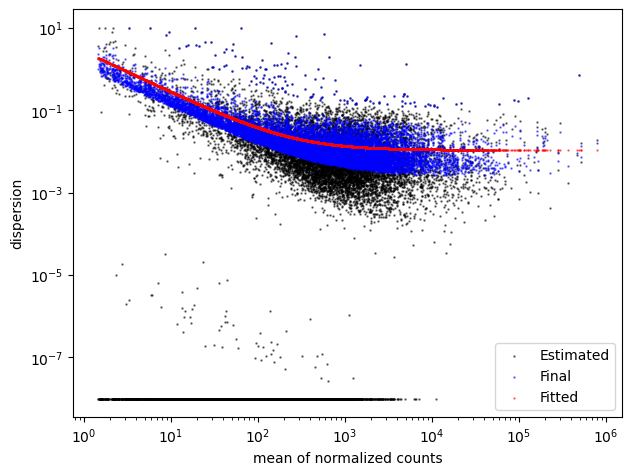

Exception ignored in: <function ResourceTracker.__del__ at 0x106935bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102491bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106919bc0>
Traceback (most recent call last

In [20]:
dds.plot_dispersions()

## 6. Statistical testing

The Wald test asks, for each gene, whether its log2 fold change differs
significantly from zero.

In [22]:
stat_res = DeseqStats(
    dds,
    contrast=["condition", TREATMENT, REFERENCE],
    alpha=ALPHA,
    quiet=True,
)
stat_res.summary()

In [23]:
results = stat_res.results_df.copy()
results.index.name = "gene"
print(f"results table: {results.shape[0]:,} genes x {results.shape[1]} columns")
results.head()

results table: 13,755 genes x 6 columns


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene,,,,,,
LOC100000024,35.013455,1.246660,0.670031,1.860601,0.062801,0.124696
LOC100000576,401.250550,-0.211609,0.220728,-0.958687,0.337717,0.468079
LOC100000851,2.215682,0.030095,1.219146,0.024685,0.980306,0.988355
LOC100001344,61.366950,-0.102598,0.245145,-0.418521,0.675566,0.772782
LOC100001550,42.240912,0.541429,0.332921,1.626300,0.103886,0.187855


### What the columns mean

| Column | Meaning |
|---|---|
| `baseMean` | Average normalised count across all samples |
| `log2FoldChange` | Effect size. +1 means twice as high in MT as in WT |
| `lfcSE` | Standard error of that estimate |
| `stat` | Wald test statistic |
| `pvalue` | Raw p-value |
| `padj` | p-value corrected for multiple testing (Benjamini-Hochberg) |

> **Always use `padj`, never `pvalue`.** We tested more than 13,000 genes. At a
> raw p < 0.05 you would expect around 700 false positives by chance alone.

## 7. How many genes changed?

In [24]:
sig = results[results["padj"] < ALPHA]
up = sig[sig["log2FoldChange"] > 0]
down = sig[sig["log2FoldChange"] < 0]

print(f"tested                       : {len(results):,}")
print(f"padj not computed (filtered) : {results['padj'].isna().sum():,}")
print(f"significant at padj < {ALPHA}   : {len(sig):,}")
print(f"  higher in {TREATMENT}                : {len(up):,}")
print(f"  higher in {REFERENCE}                : {len(down):,}")

tested                       : 13,755
padj not computed (filtered) : 3
significant at padj < 0.05   : 5,690
  higher in MT                : 2,821
  higher in WT                : 2,869


Some genes have `padj = NaN`. That is deliberate: PyDESeq2 removes genes flagged
as outliers, and applies independent filtering to low-count genes that could
never reach significance. Excluding them increases the power to detect the rest.

### 7.1 The strongest hits

In [25]:
print("--- most significant genes ---")
print(results.sort_values("padj").head(10).round(4))

--- most significant genes ---
              baseMean  log2FoldChange   lfcSE     stat  pvalue  padj
gene                                                                 
col28a1a     2833.9290         -3.4336  0.1033 -33.2240     0.0   0.0
hspa5       10045.9772          1.8818  0.0732  25.6949     0.0   0.0
hsp90b1     10429.0066          1.6877  0.0666  25.3379     0.0   0.0
serpinh1b    8260.0331          3.7190  0.1629  22.8246     0.0   0.0
col5a2a     14256.3347         -1.5832  0.0779 -20.3316     0.0   0.0
tppp3         528.6032         -2.5937  0.1286 -20.1651     0.0   0.0
zgc:86709    7572.8170          1.9228  0.0954  20.1553     0.0   0.0
matn3a       3985.4636         -1.7230  0.0878 -19.6202     0.0   0.0
hsp90aa1.2   4175.0932          3.4863  0.1793  19.4458     0.0   0.0
hsp70.1      1741.8390          3.2891  0.1699  19.3556     0.0   0.0


In [26]:
print("--- largest increases in the mutant ---")
strong = results[(results["padj"] < ALPHA) & (results["baseMean"] > 50)]
print(strong.sort_values("log2FoldChange", ascending=False).head(10).round(4))

--- largest increases in the mutant ---
             baseMean  log2FoldChange   lfcSE    stat  pvalue    padj
gene                                                                 
mhc1uba       75.3264          9.8991  1.9479  5.0819  0.0000  0.0000
zgc:114037    54.0912          7.4951  1.9875  3.7711  0.0002  0.0008
zgc:194989   153.7950          7.2756  1.4254  5.1043  0.0000  0.0000
zgc:173585   277.0915          7.1614  1.3317  5.3776  0.0000  0.0000
rn7sk       5039.0651          6.5056  1.3698  4.7493  0.0000  0.0000
zgc:153409   165.7115          6.0890  1.3820  4.4058  0.0000  0.0001
hist1h4l     207.7946          5.7031  1.2638  4.5128  0.0000  0.0000
rpph1        215.5775          5.5394  1.4312  3.8704  0.0001  0.0006
zgc:173552   107.2477          5.4377  1.3077  4.1582  0.0000  0.0002
zgc:165555   123.4452          5.3318  1.2363  4.3128  0.0000  0.0001


In [27]:
print("--- largest decreases in the mutant ---")
print(strong.sort_values("log2FoldChange").head(10).round(4))

--- largest decreases in the mutant ---
             baseMean  log2FoldChange   lfcSE     stat  pvalue    padj
gene                                                                  
hoxb13a       80.2070         -5.7685  1.3747  -4.1963  0.0000  0.0002
zgc:165461    73.2432         -5.5619  0.5615  -9.9061  0.0000  0.0000
hoxc13a      123.0445         -5.4282  0.4222 -12.8574  0.0000  0.0000
hoxc12a      266.7219         -5.2855  1.6818  -3.1427  0.0017  0.0060
neu3.2        82.3421         -4.4948  0.4111 -10.9342  0.0000  0.0000
ankrd1b     1513.1831         -4.2779  1.3431  -3.1850  0.0014  0.0053
hoxc13b       61.3224         -3.9999  0.3962 -10.0966  0.0000  0.0000
pdlim3a       52.8888         -3.9835  0.4721  -8.4384  0.0000  0.0000
scn4aa        98.6589         -3.8857  0.3196 -12.1594  0.0000  0.0000
capzb       4813.0287         -3.8455  0.2266 -16.9675  0.0000  0.0000


We filtered on `baseMean > 50` for those two tables. Genes with very low counts
can show huge fold changes that are mostly noise — always sanity-check effect
size against expression level.

## 8. Export the results

In [28]:
out_tsv = OUT / "pydeseq2_results.tsv"
out_xlsx = OUT / "pydeseq2_results.xlsx"

results.to_csv(out_tsv, sep="\t")
results.to_excel(out_xlsx)

print(f"wrote {out_tsv}  ({out_tsv.stat().st_size:,} bytes)")
print(f"wrote {out_xlsx} ({out_xlsx.stat().st_size:,} bytes)")

wrote ../results/py/pydeseq2_results.tsv  (1,722,803 bytes)
wrote ../results/py/pydeseq2_results.xlsx (1,267,657 bytes)


We also save the normalised counts, which are useful for plotting later.

In [29]:
norm.T.to_csv(OUT / "normalised_counts.tsv", sep="\t")
print(f"wrote {OUT / 'normalised_counts.tsv'}")

wrote ../results/py/normalised_counts.tsv


## 9. Does this agree with the R track?

The R course runs DESeq2 on exactly this data and its output is committed to the
repository. Since PyDESeq2 is an independent re-implementation, we can check the
two against each other directly.

In [30]:
r_results = pd.read_csv(repo_path("results/DESeq2_results.tsv"), sep="\t").set_index("gene")

both = results.join(r_results, how="inner", lsuffix="_py", rsuffix="_r")
print(f"genes in the R result  : {len(r_results):,}")
print(f"genes in our result    : {len(results):,}")
print(f"genes in common        : {len(both):,}")

genes in the R result  : 13,755
genes in our result    : 13,755
genes in common        : 13,755


In [31]:
from scipy.stats import pearsonr, spearmanr

lfc = both[["log2FoldChange_py", "log2FoldChange_r"]].dropna()

print("log2 fold change")
print(f"  Pearson  r  = {pearsonr(lfc.iloc[:, 0], lfc.iloc[:, 1])[0]:.6f}")
print(f"  Spearman r  = {spearmanr(lfc.iloc[:, 0], lfc.iloc[:, 1])[0]:.6f}")
print(f"  max |diff|  = {(lfc.iloc[:, 0] - lfc.iloc[:, 1]).abs().max():.4f}")

print("\nbaseMean")
print(f"  max |diff|  = {(both['baseMean_py'] - both['baseMean_r']).abs().max():.3e}")

log2 fold change
  Pearson  r  = 0.986177
  Spearman r  = 1.000000
  max |diff|  = 14.5623

baseMean
  max |diff|  = 6.985e-10


In [32]:
sig_py = set(results.index[results["padj"] < ALPHA])
sig_r = set(r_results.index[r_results["padj"] < ALPHA])

print(f"significant in R only  : {len(sig_r - sig_py)}")
print(f"significant in PY only : {len(sig_py - sig_r)}")
print(f"significant in both    : {len(sig_py & sig_r):,}")
print(f"Jaccard similarity     : {len(sig_py & sig_r) / len(sig_py | sig_r):.4f}")

significant in R only  : 12
significant in PY only : 9
significant in both    : 5,681
Jaccard similarity     : 0.9963


### 9.1 The one gene where they really disagree

The Pearson correlation above is dragged down by a single gene. It is worth
looking at, because it teaches something about the method.

In [33]:
diff = (lfc.iloc[:, 0] - lfc.iloc[:, 1]).abs().sort_values(ascending=False)
worst = diff.index[0]

print(f"largest disagreement: {worst}")
print(both.loc[[worst], ["log2FoldChange_py", "log2FoldChange_r", "baseMean_py"]].round(3))
print(f"\nits raw counts:")
print(counts.loc[[worst]])

largest disagreement: nkd2b
       log2FoldChange_py  log2FoldChange_r  baseMean_py
gene                                                   
nkd2b              6.677            21.239        18.77

its raw counts:
         WT_48hpf_R1  WT_48hpf_R2  WT_48hpf_R3  MT_48hpf_R1  MT_48hpf_R2  \
gene_id                                                                    
nkd2b              0            0            0           74            0   

         MT_48hpf_R3  
gene_id               
nkd2b              0  


In [34]:
lfc_clean = lfc.drop(index=[worst])
print(f"correlation EXCLUDING that one gene (n = {len(lfc_clean):,}):")
print(f"  Pearson  r = {pearsonr(lfc_clean.iloc[:, 0], lfc_clean.iloc[:, 1])[0]:.6f}")
print(f"  max |diff| = {(lfc_clean.iloc[:, 0] - lfc_clean.iloc[:, 1]).abs().max():.6f}")

correlation EXCLUDING that one gene (n = 13,754):
  Pearson  r = 1.000000
  max |diff| = 0.002555


That gene is zero in every wild-type sample and non-zero in exactly one mutant
sample. When a gene is completely absent from one group, the true log2 fold
change is mathematically **infinite** — the maximum-likelihood estimate does not
converge, and each implementation simply reports wherever its optimiser stopped.
The two numbers look wildly different but carry the same meaning: *on in one
group, off in the other*.

**The conclusion.** Apart from that single degenerate case, the two
implementations agree to about three decimal places on every gene, rank genes
identically, and pick nearly the same significant set. You can teach either
track and get the same biology.

It is still worth telling students the two are not bit-identical. They use
different optimisers, so tiny numerical differences are expected and normal.

## 10. Exercises

1. How many genes have `padj < 0.01` instead of 0.05?
2. Find the gene with the largest `baseMean`. Is it differentially expressed?
3. Re-run the filter in section 3 with a threshold of 50 instead of 10. How many
   genes survive, and how many are significant now? Why did the number of
   significant genes change even for genes that were never filtered out?
4. Write out only the significant genes, sorted by `log2FoldChange`.

*(Question 3 is the important one: the multiple-testing correction depends on how
many tests you ran, so filtering changes the results for every gene.)*

#### exercise 1

In [36]:
#count genes with padj < 0.01
sig_genes = results[results["padj"] < 0.01]
num_sig_genes = len(sig_genes)
print(f"Number of significant genes (padj < 0.01): {num_sig_genes}")

Number of significant genes (padj < 0.01): 4185


#### exercise 2

In [37]:
# Find gene with largest baseMean
max_base_mean_gene = results["baseMean"].idxmax()
max_base_mean_value = results["baseMean"].max()

# Check if it's differentially expressed
is_significant = results.loc[max_base_mean_gene, "padj"] < ALPHA

print(f"Gene with largest baseMean: {max_base_mean_gene}")
print(f"Largest baseMean value: {max_base_mean_value:.2f}")
print(f"Is it differentially expressed (padj < 0.05)? {'Yes' if is_significant else 'No'}")

Gene with largest baseMean: myhz1.1
Largest baseMean value: 796875.63
Is it differentially expressed (padj < 0.05)? Yes


#### exercise 3

In [ ]:
# Re-run the filter with threshold of 50
total_per_gene = counts_t.sum(axis=0)
keep = total_per_gene >= 50

print(f"genes removed   : {(~keep).sum():,}")
print(f"genes remaining : {keep.sum():,}")

# Apply the new filter
counts_t_filtered = counts_t.loc[:, keep]

# Rebuild the DESeq dataset with the filtered data
dds_filtered = DeseqDataSet(
    counts=counts_t_filtered,
    metadata=metadata,
    design="~condition",
    refit_cooks=True,
    quiet=True,
)

# Fit the model
dds_filtered.deseq2()

# Perform statistical testing
stat_res_filtered = DeseqStats(
    dds_filtered,
    contrast=["condition", TREATMENT, REFERENCE],
    alpha=ALPHA,
    quiet=True,
)

stat_res_filtered.summary()

results_filtered = stat_res_filtered.results_df.copy()
results_filtered.index.name = "gene"

# Count significant genes
sig_filtered = results_filtered[results_filtered["padj"] < ALPHA]
num_sig_filtered = len(sig_filtered)

print(f"Genes surviving filter: {len(results_filtered):,}")
print(f"Significant genes (padj < 0.05): {num_sig_filtered:,}")

# Compare to original
print(f"Original significant genes: {len(sig):,}")
print(f"Change in significant genes: {num_sig_filtered - len(sig)}")

genes removed   : 550
genes remaining : 13,205
Genes surviving filter: 13,205
Significant genes (padj < 0.05): 5,713
Original significant genes: 5,690
Change in significant genes: 23


Exception ignored in: <function ResourceTracker.__del__ at 0x10680dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1068fdbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104955bc0>
Traceback (most recent call last

#### exercise 4

In [40]:
# Filter for significant genes and sort by log2FoldChange
sig_genes = results[results["padj"] < ALPHA].sort_values("log2FoldChange", ascending=False)

# Write to file
out_file = OUT / "significant_genes_sorted_by_log2fc.tsv"
sig_genes.to_csv(out_file, sep="\t")

print(f"Significant genes sorted by log2FoldChange written to: {out_file}")

Significant genes sorted by log2FoldChange written to: ../results/py/significant_genes_sorted_by_log2fc.tsv


## 11. Session information

In [ ]:
import sys

try:
    import session_info

    session_info.show()
except ModuleNotFoundError:
    # Not an error in your code: this kernel simply does not have session-info.
    # It ships with the course environment (setup/python/environment.yml).
    # The interpreter path below is the fastest way to see which Python the
    # notebook is actually using, which is usually the real problem.
    print("session-info is not installed in this kernel.")
    print("kernel:", sys.executable)
    print("See setup/python/README.md to select the ZebraQ environment.")